<a href="https://colab.research.google.com/github/fatihonay/Neural-Variability-/blob/main/docs/source/Tutorials/Aper_Osc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEG: The Clash of Aperiodic and Periodic Powers

EEG signals can be studied in both the `time` and `frequency` domains. In the `time domain`, we can only see fluctuations and rapid transient activity. If we are lucky, we may see strong oscillatory activity. However, for broadband EEG signals, it is generally hard to see clear oscillations. On the other hand, the `frequency domain` of an EEG signal may give much more abstract information associated with the blueprint of underlying neural dynamics

> Okay, now my question is: What is the most prominent feature both time and frequency domains share?

Let's think step-by-step to answer this question. We can use special transformation techniques which can provide meaningful information representation. The fundamental transformation converting signal from time domain to frequency domain is Fourier Transform.

The amount of information (variance) remains constant during this transformation. Only its representation changes from a timeline of voltage to a distribution of power across frequencies. As a result of this fact, power of the signal is pereserved (see; Parseval's Theorem).

> Answer is power. It is the common feature of both time and frequency domain representation.

That's why Power Spectral Density analysis is so common in EEG literature. It is universal feature of the signal. However, there ara some issues about this. We will talk about them but firstly we should play with EEG :)

I will use resting state EEG signal from OpenNeuro with the following details;

https://openneuro.org/datasets/ds006923/versions/1.0.0

For this tutorial, let's use subject with number 2082.



In [4]:
!pip install mne
import mne
import os

# I denote datapath from my drive
data_dir = '/content/drive/MyDrive/Juvenile_resting_Subj'

# Let's find the .set file for EEG
found_file = None
for filename in os.listdir(data_dir):
    if filename.endswith('.set'):
        found_file = filename
        break

# Full file path
file_path = os.path.join(data_dir, found_file)
print(f"Found epoched file: {found_file}")

# Import data
epochs = mne.io.read_epochs_eeglab(file_path)

print(epochs)
print(epochs.info)


Found epoched file: sub-2082cg_task-restingstate_acq-epochs_eeg.set
Extracting parameters from /content/drive/MyDrive/Juvenile_resting_Subj/sub-2082cg_task-restingstate_acq-epochs_eeg.set...
Not setting metadata
4 matching events found
No baseline correction applied
0 projection items activated
Ready.
<EpochsEEGLAB | 4 events (all good), 0 – 49.992 s (baseline off), ~25.1 MiB, data loaded,
 'PostClosed': 2
 'PostOpen': 2>
<Info | 8 non-empty values
 bads: []
 ch_names: A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, A12, A13, A14, ...
 chs: 128 EEG
 custom_ref_applied: False
 dig: 131 items (3 Cardinal, 128 EEG)
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 128
 projs: []
 sfreq: 128.0 Hz
>


This is 128-channel EEG data with 128 Hz sampling frequency. For this tutoriali we will only analysis single channel EEG signal.

Let's visualize in time domain

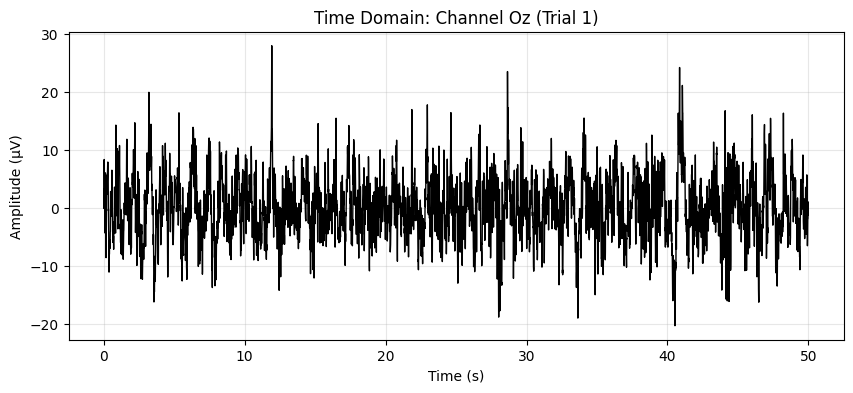

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Let's pick Oz channel
channel_idx = 22 # Oz channel
epoch_idx   = 0    # First trial

# 2. Extract the data (n_epochs, n_channels, n_times)
data                  = epochs.get_data()
single_channel_signal = data[epoch_idx, channel_idx, :]

# 3. Create the time vector
time_axis = epochs.times

# 4. Plot
plt.figure(figsize=(10, 4))
plt.plot(time_axis, single_channel_signal * 1e6, color='k', linewidth=1)

plt.title(f"Time Domain: Channel Oz (Trial {epoch_idx+1})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")  # MNE usually stores in Volts, but labels often µV
plt.grid(True, alpha=0.3)
plt.show()

Fascinating ! We can clearly see broadband EEG signal with rapid fluctuations. Now let's visit frequency domain :)

Sampling frequency is 128.0 Hz


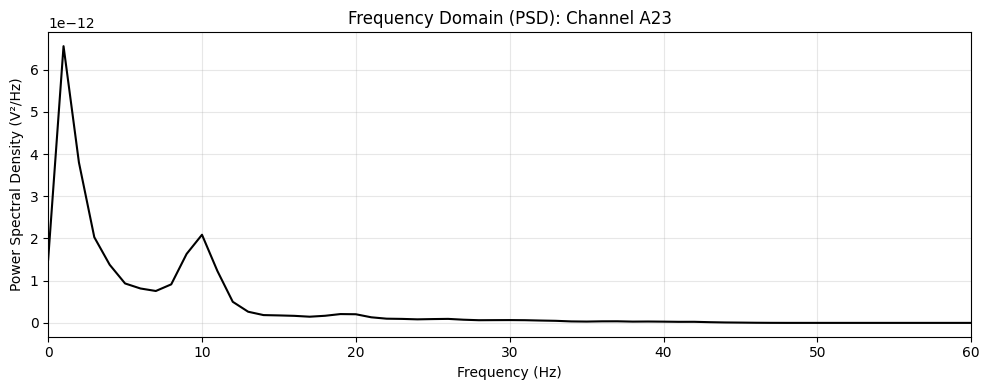

In [6]:
from scipy.signal import welch

# 1. Define Sampling Frequency (Fs)
fs = epochs.info['sfreq']
print(f'Sampling frequency is {fs} Hz')

# 2. Compute Power Spectral Density (PSD)
freqs, psd = welch(single_channel_signal, fs=fs, nperseg=128)

# 3. Plot
plt.figure(figsize=(10, 4))
plt.plot(freqs, psd, color='k', linewidth=1.5)

# Formatting to make it clear
plt.title(f"Frequency Domain (PSD): Channel {epochs.ch_names[channel_idx]}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.grid(True, alpha=0.3)

# Limit x-axis to Nyquist frequency (Fs/2) or a reasonable range like 0-60Hz
plt.xlim(0, 60)

plt.tight_layout()
plt.show()

Okkeyy, we did it ! The PSD clearly indicates two peaks at around 1 Hz and 10 Hz. Since this data is clean (pre-processed), we see very clean and smooth PSD.

We can see the peak around 10 Hz at Oz electrode in eyes-closed condition. Another peak is due to the 1-40Hz band-pass filtering in the pre-processing phase. Actually, it is not peak. It is important to remember that EEG power follows a 1/f (pink noise) distribution. Power is naturally highest at lower frequencies.



## Oscillations

Now, we know that there is a strong oscillatory activity within alpha band (8 - 12 Hz). Im my opinion, we should check activities in all sub-bands of EEG to compare the oscillatory activity across `delta`, `theta`, `alpha`,and `beta`bands.

Let's perform filtering on the signal to separat broad-band EEG into its narrow-bands.


Filtered delta band (0.5-4 Hz)
Filtered theta band (4-8 Hz)
Filtered alpha band (8-12 Hz)
Filtered beta band (13-30 Hz)


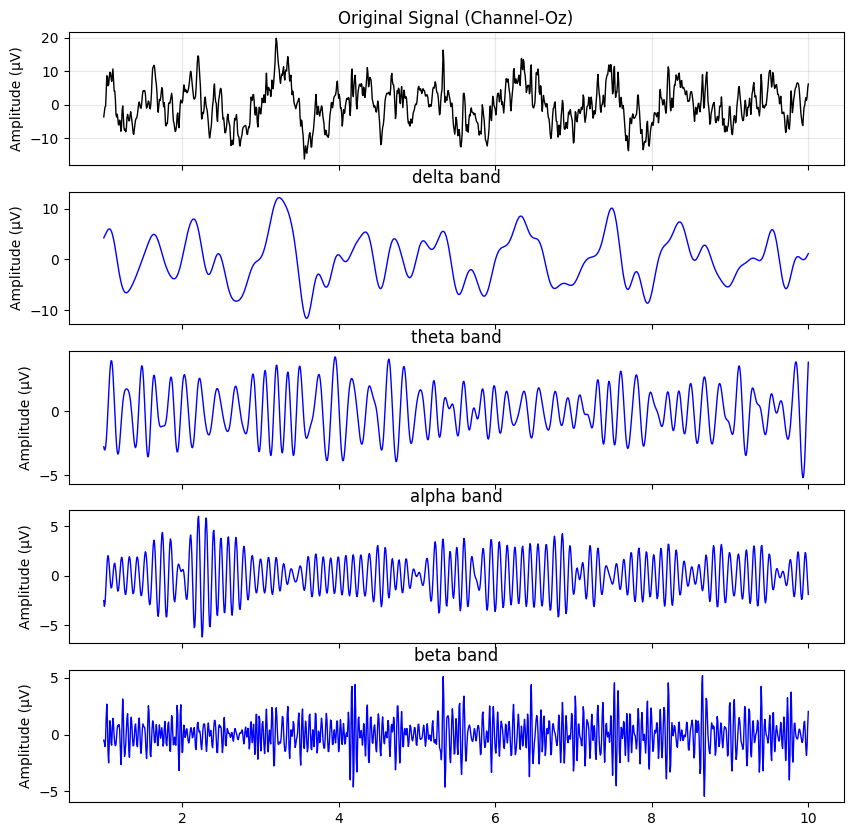

In [40]:
from scipy.signal import butter, filtfilt

# Determine sub-band ranges
sub_bands = {
    'delta': (0.5,4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (13,30)}

# Let's design our filter
def butter_bandpass(data, lowcut, highcut, fs, order = 4):
  nyq = 0.5*fs
  low = lowcut/nyq
  high = highcut/nyq
  b, a = butter(order, [low, high], btype='band')

  # filtfilt applies the filter forward and backward (zero-phase distortion)
  y = filtfilt(b, a, data)
  return y


# Create a dictionary to store the results
filtered_signals = {}

# Let's determine time range we want to visualize
t_start   = 1
t_end     = 10
mask      = (time_axis >= t_start) & (time_axis <= t_end)
time_wind = time_axis[mask]


# Create subplot fig
fig, axes = plt.subplots(5,1, figsize=(10,10), sharex=True)
time_axis = epochs.times

# Plot Original Signal
axes[0].plot(time_wind, single_channel_signal[mask] * 1e6, color='k', linewidth=1)
axes[0].set_title("Original Signal (Channel-Oz)")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylabel('Amplitude (µV)')


# Iterate over the sub-bands
for i, (sub_band, (fmin, fmax)) in enumerate(sub_bands.items()):

    ax = axes[i + 1]

    signal_subband = butter_bandpass(single_channel_signal, fmin, fmax, fs)

    print(f'Filtered {sub_band} band ({fmin}-{fmax} Hz)')

    ax.plot(time_wind, signal_subband[mask] * 1e6,color='b', linewidth=1)
    ax.set_title(f'{sub_band} band')
    ax.set_ylabel('Amplitude (µV)')



We only visualized a small portion of signal to see details easily. Each sub-band has its own oscillatory activity. Actually, weak or strong we always observe oscillatory activity after performing narrow-band filtering. It is somehow misleading. Because aperiodic activity spans entire frequency spectrum.

You know what?

This is a problem. We only want to see pure oscillatory activity related to specific sub-band but aperiodic component conflates with oscillatory neural activity.

Now, let's review this problem with an example.